## **i. Perkenalan**

1. Nama       : Fawwaz Rif'at Revista
2. Batch      : RMT-039
3. Objective  : Membuat model machine learning yang dapat memprediksi popularitas Pulau Pari selama 1 tahun kedepan dengan menggunakan dataset Google Trends

## **ii. Import Libraries**

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pylab
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

## **iii. Data Loading**

In [2]:
# Load data mneggunakan Pandas
pari_data = pd.read_csv('multiTimeline.csv')
pari_data

,Category: All categories
2022-03-27,16
2022-04-03,13
2022-04-10,18
2022-04-17,29
2022-04-24,35
...,...
2024-07-21,43
2024-07-28,34
2024-08-04,32
2024-08-11,36


In [3]:
# Mengganti nama fitur Category
pari_data = pari_data.rename(columns={'Category: All categories' : 'popularity'})

In [4]:
# Reset index agar fitur tanggal dapat diubah menjadi DateTime
pari_data.reset_index(inplace=True)

In [5]:
# Mengganti nama kolom Index menjadi Date
pari_data.rename(columns={'index' : 'date'}, inplace=True)

In [6]:
pari_data

,date,popularity
0,2022-03-27,16
1,2022-04-03,13
2,2022-04-10,18
3,2022-04-17,29
4,2022-04-24,35
...,...,...
121,2024-07-21,43
122,2024-07-28,34
123,2024-08-04,32
124,2024-08-11,36


In [7]:
# Mengubah tipe data date
pari_data['date'] = pd.to_datetime(pari_data['date'], format = '%Y-%m-%d')
# Menjadikan fitur date sebagai index
pari_data.set_index('date', inplace=True)

In [8]:
# Menampilkan dataset
pari_data

,popularity
date,
2022-03-27,16
2022-04-03,13
2022-04-10,18
2022-04-17,29
2022-04-24,35
...,...
2024-07-21,43
2024-07-28,34
2024-08-04,32


In [9]:
# Splitting data
train = pari_data[:102]
test = pari_data[102:]

print('Train : ',train.shape)
print('Test  : ',test.shape)

Train :  (102, 1)
Test  :  (24, 1)


Data dipisah berdasarkan persentase, dimana data train mengandung 80% dari keseluruhan data.

## **iv. Exploratory Data Analysis (EDA)**

# Visualisasi

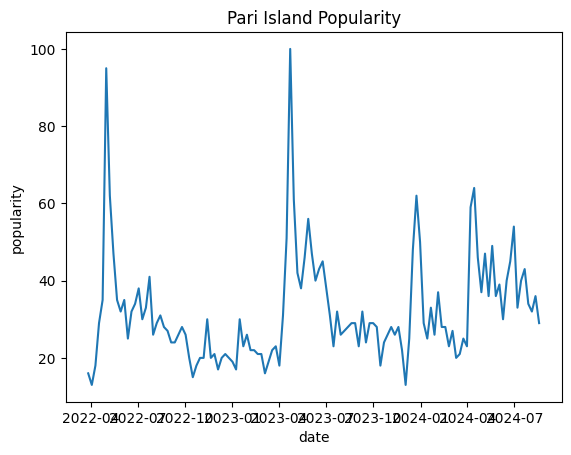

In [10]:
# Visualisasi Lineplot popularity menggunakan data asli
sns.lineplot(data=pari_data, x='date', y='popularity')
plt.title('Pari Island Popularity')
plt.show()

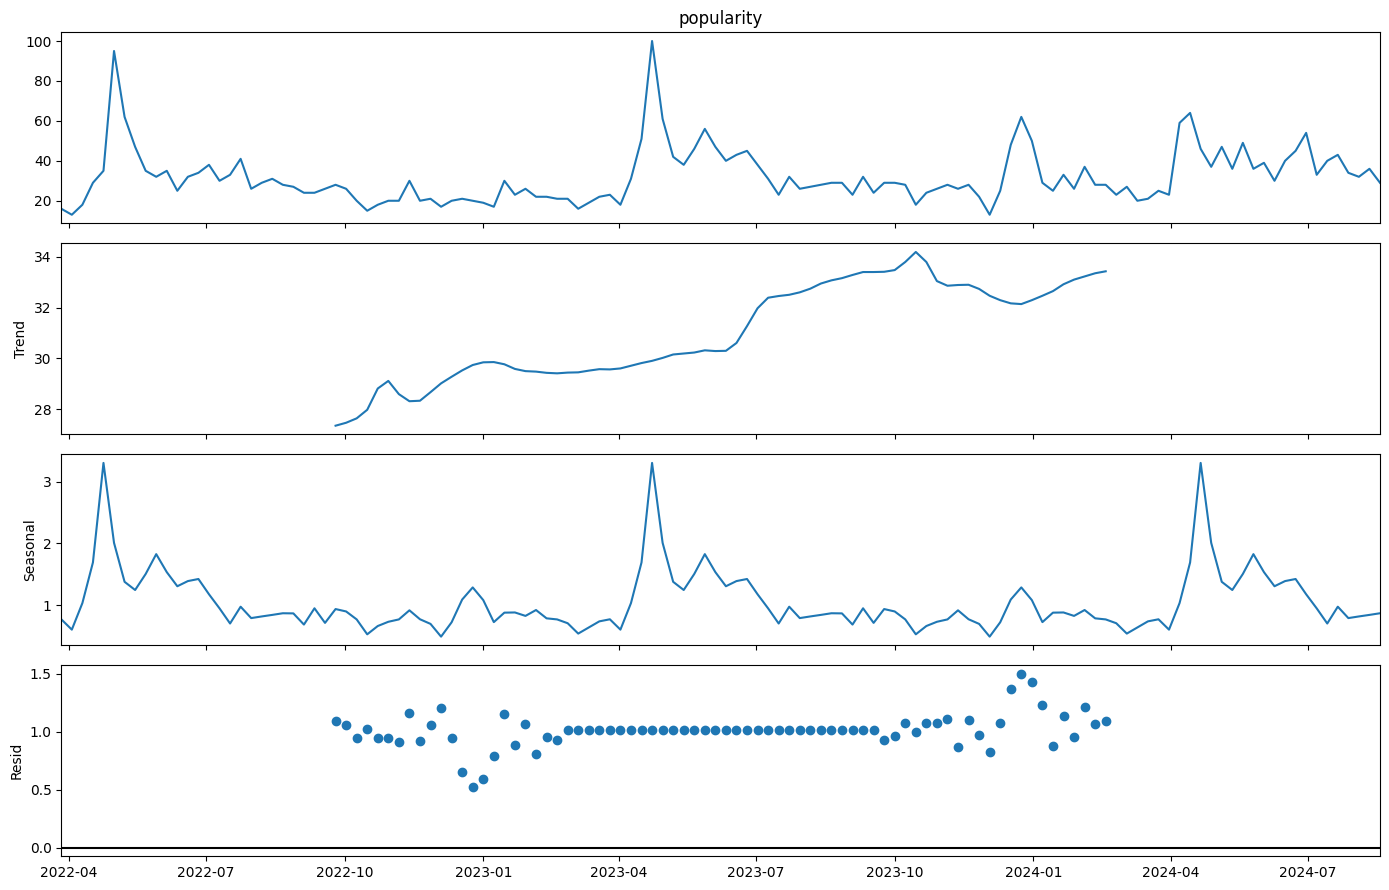

In [11]:
# Dekomposisi Multiplicative
pylab.rcParams['figure.figsize'] = (14, 9)
res = seasonal_decompose(pari_data['popularity'], model='multiplicative')
ax=res.plot()
plt.show()

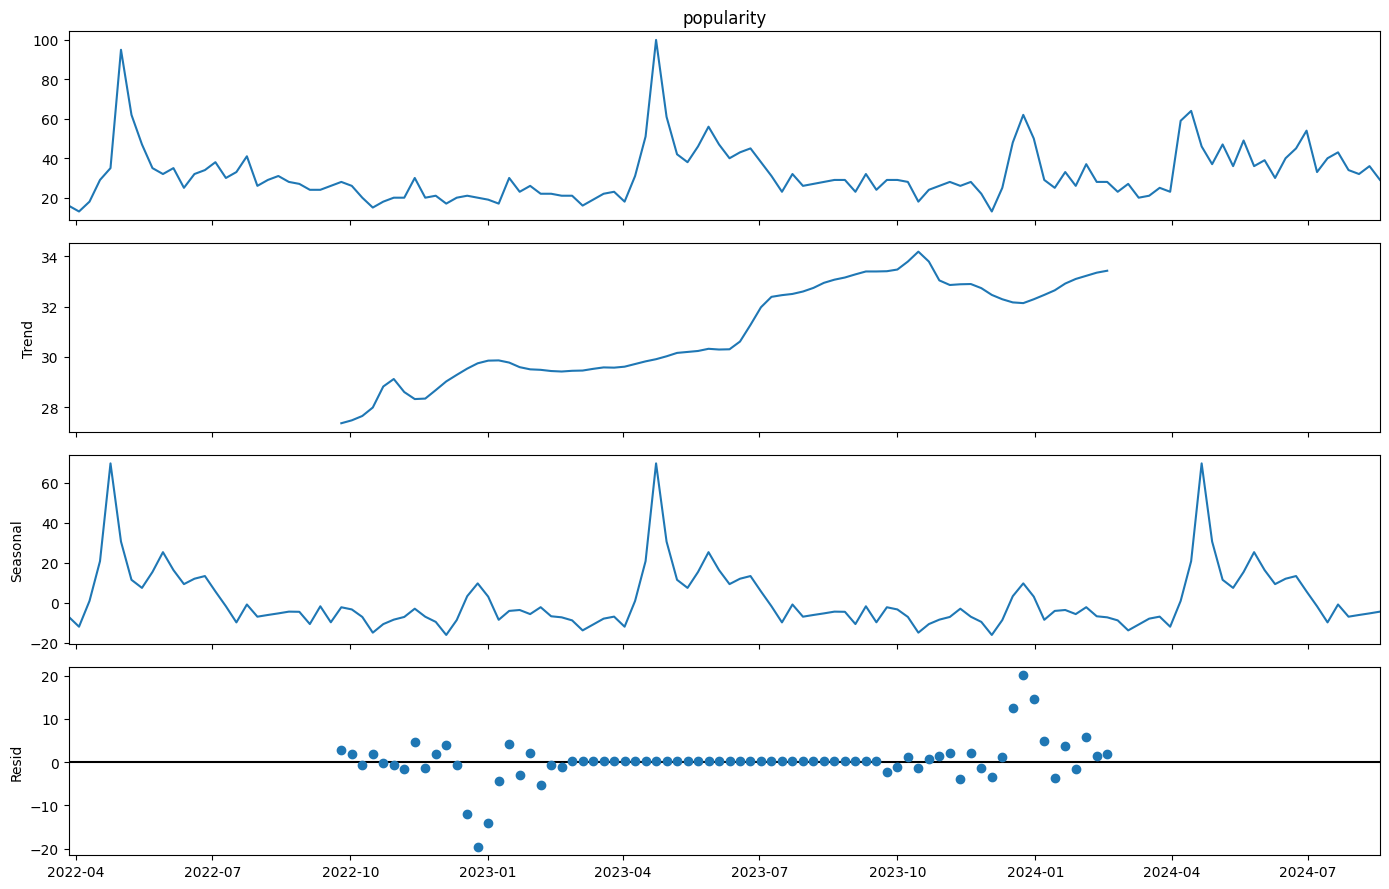

In [12]:
# Dekomposisi Additive
pylab.rcParams['figure.figsize'] = (14, 9)
res = seasonal_decompose(pari_data['popularity'], model='additive')
ax=res.plot()
plt.show()

Berdasarkan visualisasi diatas, dapat dilihat bahwa pada model Multiplicative, nilai residual yang didapatkan tidak memiliki gap yang jauh, sehingga model Multiplicative akan lebih cocok digunakan untuk melakukan prediksi. Prediksi yang melibatkan season/model Multiplicative ini akan digunakan pada saat modelling dengan SARIMA.
Model additive memiliki nilai residual yang lebih jauh/ memiliki gap yang lebih jauh, hal ini wajar karena popularitas Pulau Pari bersifat musiman. Oleh karena itu, nilai residual yang tinggi pada Additive dapat dimaklumi.

In [13]:
# Create a function to check stationarity

def check_stationarity(series):

    result = adfuller(series.values)

    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

    if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")

In [14]:
# Uji Stasioner Data
check_stationarity(train['popularity'])

ADF Statistic: -3.496357
p-value: 0.008081
Critical Values:
	1%: -3.499
	5%: -2.892
	10%: -2.583
Stationary


Berdasarkan hasil uji stasioner, didapatkan hasil bahwa data yang digunakan saat ini sudah memenuhi/lulus uji stasioner, sehingga tidak perlu untuk dilakukan differencing yang juga membuat nilai d(differecing) pada dataset ini adlaah 0 karena tidak dilakukan differencing.

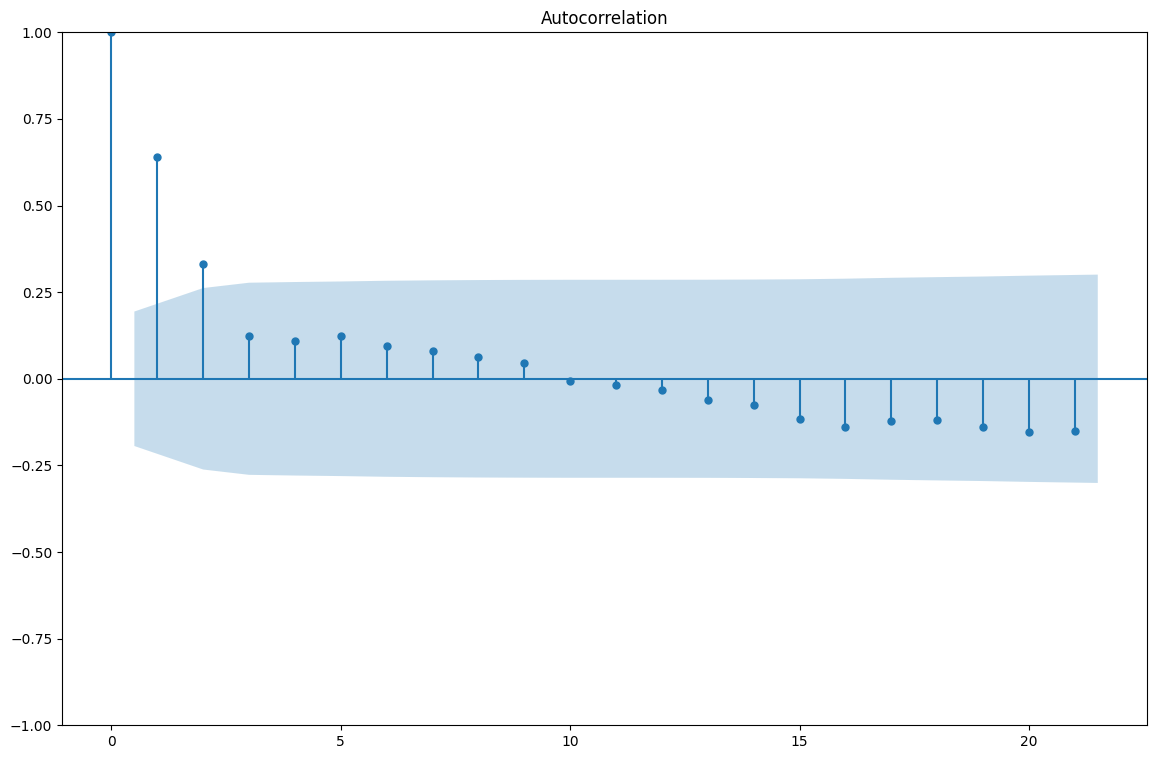

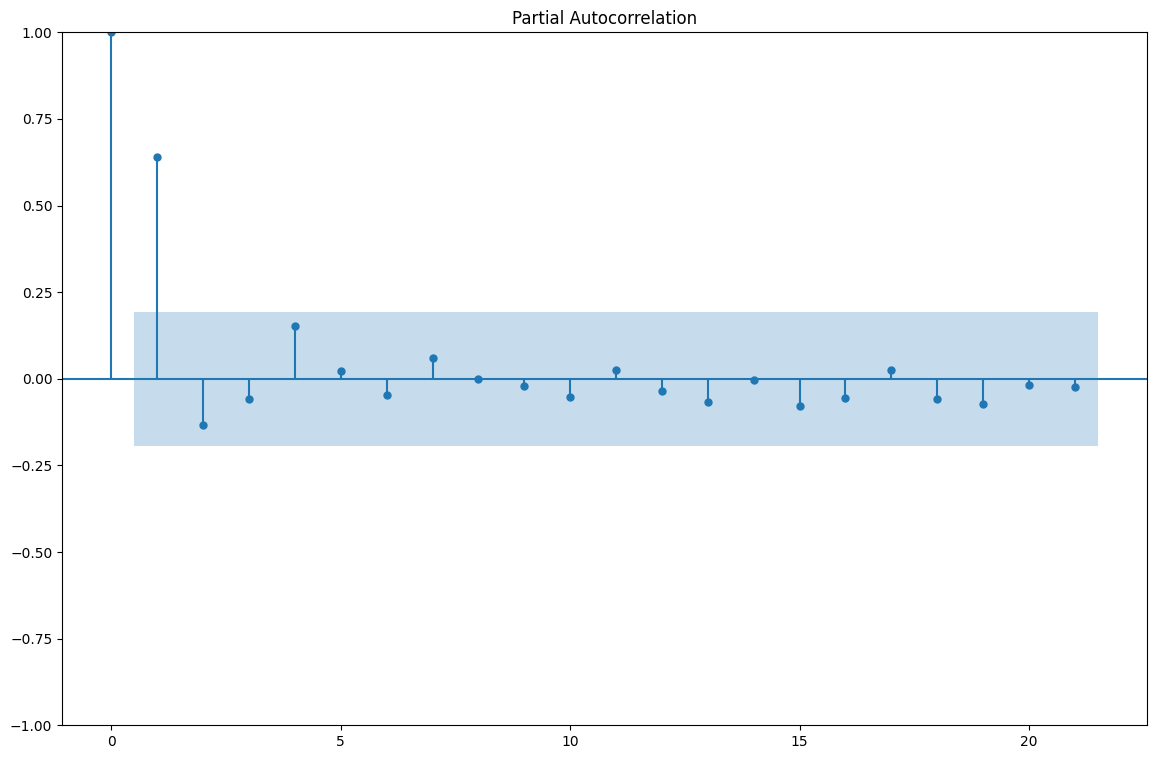

In [15]:
# Membuat plot ACF & PACF untuk menentukan nilai q & p
plot_acf(train['popularity'])
plot_pacf(train['popularity'])
plt.show()

Gambar 1 merupakan Plot ACF yang digunakan untuk mendapatkan nilai q. Pada gambar 1 didapatkan nilai lags = 2 dan cutsoff = 3. Nilai yang digunakan untuk menentukan nilai 1 adalah nilai lags, sehingga nilai q yang didapatkan adalah 2.
Gambar 2 merupakan visualisasi dari Plit PACH yang digunakan untuk menentukan nilai p. Pada visualisasi plot tersebut dapat dilihat bahwa nilai lags yang didapatkan adalah 1, sedangkan nilai cutsoffnya adalah 2. Nilai yang digunakan untuk menentukan nilai p adalah nilai lags, sehingga nilai p yang didapatkan adalah 1.
Setelah didapatkan nilai p,d,q maka sudah didapatkan parameter terbaik yang dapat digunakan untuk membuat model machine laerning dalam memprediksi popularitas Pulau Pari, yaitu 1,0,2

## **v. Model Definition and Training**

# **ARIMA**

In [16]:
# Create a function to find best model

def find_best_model(data, num_p, num_d, num_q):
  df = pd.DataFrame() #We make a pandas dataframe to ease our work, you can use any way that makes you comfortable and work easly
  pdq = [[],[],[]] #This list for storing the combinations of p and q
  aic = [] # This list for storing aic value
  for p in range(num_p + 1): #plus one is to make the range up to num_p since python range only ranging from 0 to N-1
    for d in range(num_d + 1):
      for q in range(num_q + 1):
        # #if p!=0 and q!=0: #this logic will avoid (0,0) value which is not correct
        try: #Using exception to avoid the error while training the model with certain p and q value
          model = ARIMA(data, order=(p, d, q))
          result = model.fit()
          pdq[0].append(p)
          pdq[1].append(d)
          pdq[2].append(q)
          aic.append(result.aic)
        except:
          pass #If there is an error caused by the calculation, it will be skipped to the next iteration

  df['p'] = pdq[0]
  df['d'] = pdq[1]
  df['q'] = pdq[2]
  df['AIC'] = aic

  df.sort_values('AIC', inplace=True)

  return df.p.iloc[0], df.d.iloc[0], df.q.iloc[0], df.AIC.iloc[0], df

In [17]:
%%time
find_best_model(train['popularity'], 1, 0, 2)

CPU times: user 1.6 s, sys: 7.46 ms, total: 1.61 s
Wall time: 1.45 s


(0,
 0,
 2,
 778.7555841904929,
    p  d  q         AIC
 2  0  0  2  778.755584
 5  1  0  2  779.954783
 3  1  0  0  780.201538
 4  1  0  1  780.904239
 1  0  0  1  793.207218
 0  0  0  0  832.367558)

In [18]:
# Train ARIMA dengan kombinasi p,d,q terbaik

model_arima_102 = ARIMA(train['popularity'], order=(1, 0, 2))
result_model_arima_102 = model_arima_102.fit()

print('The AIC is ', result_model_arima_102.aic)

The AIC is  779.9547834910996


In [19]:
# Melakukan evaluasi denga data test

# Jumlah baris dataset test
len_dataset = test.shape[0]
# Angka 43 untuk 24 minggu setealh tanggal terakhir data train
len_predict = len_dataset + 23

# Melakukan prediksi terbaru
new_pred = result_model_arima_102.predict(len_dataset, len_predict)
new_pred = pd.DataFrame(new_pred)
# Membuat kolom baru yang berisi nilai prediksi popularitas
new_pred.columns=['pred']
all_dataset_with_pred = pd.concat([test, new_pred], axis=0)

# **SARIMA**

In [20]:
# Mealtih model dengan SARIMA berda
%%time
sar=SARIMAX(train['popularity'], order=(1, 0, 2),seasonal_order=(1, 0, 2, 48)).fit()
sar.summary()

CPU times: user 1min 11s, sys: 440 ms, total: 1min 12s
Wall time: 1min 26s


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         popularity   No. Observations:                  102
Model:             SARIMAX(1, 0, 2)x(1, 0, 2, 48)   Log Likelihood                -393.258
Date:                            Mon, 20 Jan 2025   AIC                            800.515
Time:                                    04:53:40   BIC                            818.890
Sample:                                03-27-2022   HQIC                           807.956
                                     - 03-03-2024                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9838      0.054     18.117      0.000       0.877       1.090
ma.L1         -0.2278      0.106     -2.140      0.032      -0.436      -0.019
ma.L2         -0.2690      0.190     -1.415      0.157      -0.641       0.104
ar.S.L48       0.9664     45.981      0.021      0.983     -89.154      91.087
ma.S.L48      -1.1486     72.599     -0.016      0.987    -143.440     141.143
ma.S.L96       0.2265     12.674      0.018      0.986     -24.614      25.067
sigma2       120.5622   3207.170      0.038      0.970   -6165.376    6406.500
===================================================================================
Ljung-Box (L1) (Q):                   0.29   Jarque-Bera (JB):              1000.99
Prob(Q):                              0.59   Prob(JB):                         0.00
Heteroskedasticity (H):               0.40   Skew:                             3.02
Prob(H) (two-sided):                  0.01   Kurtosis:                        17.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Berdasarkan nilai AIC, ARIMA memiliki nilai AIC yang sedikit lebih baik dibandingkan SARIMA karena memiliki nilai AIC yang lebih rendah.

In [21]:
# Melakukan Prediksi

## Memprediksi test set
sar_pred_test = sar.predict(start="2024-03-10", end="2024-08-18")
sar_pred_test = pd.DataFrame(sar_pred_test)
sar_pred_test.columns = ['popularity_sold_predict']

## Menggabungkan nilai aktual dengan prediksi
act_vs_pred_sar=pd.concat([test, sar_pred_test], axis=1)
act_vs_pred_sar

,popularity,popularity_sold_predict
2024-03-10,20,25.099358
2024-03-17,21,21.404541
2024-03-24,25,13.724174
2024-03-31,23,18.530579
2024-04-07,59,20.929932
2024-04-14,64,20.606474
2024-04-21,46,19.545074
2024-04-28,37,17.954646
2024-05-05,47,19.068110
2024-05-12,36,19.284724


## **vi. Model Evaluation**

In [22]:
# Cek MAE & RMSE ARIMA
print('MAE test  : ', mean_absolute_error(test, new_pred))
print('RMSE test : ', np.sqrt(mean_squared_error(test, new_pred)))

MAE test  :  14.510405447007377
RMSE test :  17.31240395806756


In [23]:
# Cek MAE & RMSE SARIMA
print('MAE test  : ', mean_absolute_error(test, sar_pred_test))
print('RMSE test : ', np.sqrt(mean_squared_error(test, sar_pred_test)))

MAE test  :  19.89324273586294
RMSE test :  22.40617268961068


Berdasarkan hasil model evaluasi, didapatkan hasil bahwa model ARIMA memiliki tingkat kesalahan/error yang lebih kecil dibandingkan dengan SARIMA, sehingga dapat disimpulkan model ARIMA merupakan model yang terbaik untuk memprediksi poplaritas Pulau Pari 1 tahun kedepan.

## **vi. Model Inference**

# Model Inference with ARIMA

In [24]:
# Prediksi 1 tahun/ 48 minggu kedepan

# Jumlah baris dataset
len_dataset = pari_data.shape[0]
# Angka 48 untuk 1 tahun kedepan dalam minggu
len_predict = len_dataset + 48

# Melakukan prediksi terbaru dimulai dari 1 minggu tanggal terakhir
new_pred_year = result_model_arima_102.predict(len_dataset, len_predict)
new_pred_year = pd.DataFrame(new_pred_year)
# Membuat kolom baru yang berisi nilai prediksi popularitas
new_pred_year.columns=['pred']
all_dataset_with_pred = pd.concat([pari_data, new_pred_year], axis=0)

In [25]:
# Menampilkan prediksi popularitas Pulau Pari 1 tahun/48 minggu kedepan
new_pred_year

,pred
2024-08-25,30.388721
2024-09-01,30.388721
2024-09-08,30.388721
2024-09-15,30.388721
2024-09-22,30.388721
2024-09-29,30.388721
2024-10-06,30.388721
2024-10-13,30.388721
2024-10-20,30.388721
2024-10-27,30.388721


Berdarakan hasil prediksi dengan ARIMA, didapatkan hasil bahwa popularitas Pulau Pari adalah 30,38 (kurang dari 50)  yang artinya popularitasnya kurang dari setengah.